Analysis starts: 2009-07-31
Analysis ends: 2026-06-30


,Static 60/40 portfolio,Trend-following portfolio
Final value of $1,3.931358,2.604762
CAGR,0.083860,0.057930
Annualised volatility,0.091581,0.065534
Sharpe ratio,0.788477,0.698845
Maximum drawdown,-0.213039,-0.084179
Worst full calendar year,-0.163466,-0.052312
Annualised turnover,0.355561,2.063397
Average cash weight,0.000000,0.265170


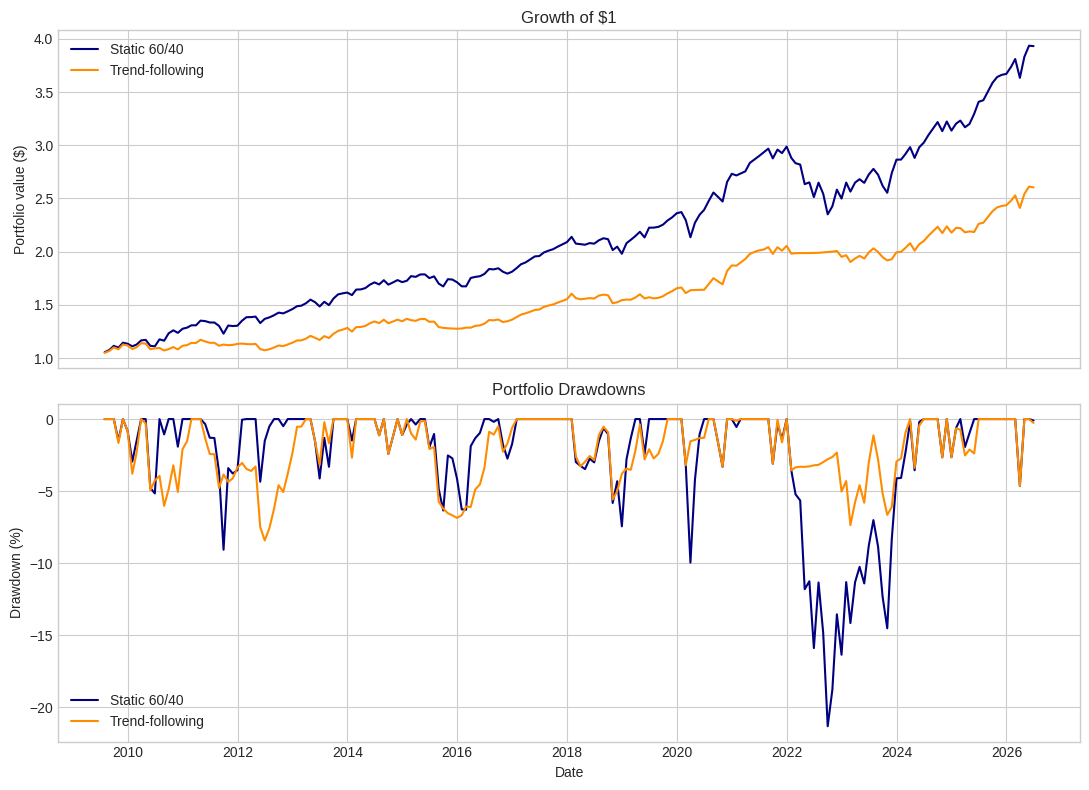

Out-of-sample period starts: 2022-04-30


,Portfolio,Final value of $1,CAGR,Annualised volatility,Sharpe ratio,Maximum drawdown
0,Static 60/40,1.394791,0.081439,0.11593,0.390756,-0.165928
1,Trend-following,1.310941,0.065778,0.07119,0.368615,-0.055779


,Moving average (months),Full-sample CAGR,Full-sample Sharpe,Full-sample maximum drawdown,10 bps full-sample CAGR,Out-of-sample CAGR,Out-of-sample Sharpe,Out-of-sample maximum drawdown
0,8,0.061188,0.754657,-0.076102,0.058811,0.060624,0.318328,-0.051519
1,10,0.057930,0.698845,-0.084179,0.055749,0.065778,0.368615,-0.055779
2,12,0.057844,0.721016,-0.073157,0.055893,0.090074,0.714352,-0.053859


95% moving-block bootstrap interval for the trend minus benchmark monthly return: [-4.23520691e-03  3.77613304e-05]


,Transaction costs,Static final value of $1,Trend final value of $1,Static CAGR,Trend CAGR,Static Sharpe ratio,Trend Sharpe ratio,Static maximum drawdown,Trend maximum drawdown
0,0 bps,3.931358,2.604762,0.083860,0.057930,0.788477,0.698845,-0.213039,-0.084179
1,10 bps,3.907667,2.514955,0.083474,0.055749,0.784510,0.666765,-0.213293,-0.086546
2,25 bps,3.872397,2.385942,0.082897,0.052483,0.778559,0.618557,-0.213674,-0.090086


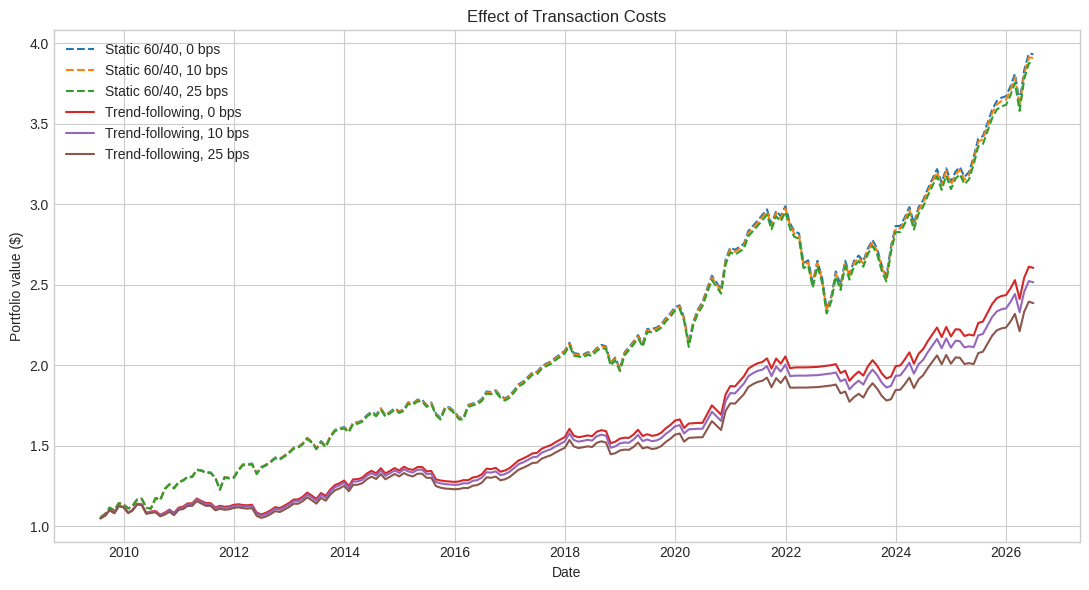

In [2]:
# ==================== CELL 1 ====================
# Install the package needed to download financial data
!pip install yfinance --quiet

# Import the packages we will use
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Make charts look clearer
plt.style.use("seaborn-v0_8-whitegrid")

# ---------------------------
# 1. Choose the assets
# ---------------------------

# VT  = broad global equities
# IEF = US government bonds
# BIL = short-term US Treasury bills, used as our cash proxy
tickers = {
    "Equities": "VT",
    "Bonds": "IEF",
    "Cash": "BIL"
}

start_date = "2008-07-01"
end_date = "2026-07-01"

# ---------------------------
# 2. Download daily prices
# ---------------------------

downloaded_data = yf.download(
    list(tickers.values()),
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False
)

# Use adjusted open and adjusted close prices.
# auto_adjust=True adjusts both columns for distributions and splits.
daily_open = downloaded_data["Open"].copy()
daily_close = downloaded_data["Close"].copy()

# Rename ticker columns so that they are easier to read
column_names = {
    ticker: name
    for name, ticker in tickers.items()
}
daily_open = daily_open.rename(columns=column_names)
daily_close = daily_close.rename(columns=column_names)

# Keep only dates where all three funds have both prices available
common_dates = (
    daily_open.dropna().index
    .intersection(daily_close.dropna().index)
)

daily_open = daily_open.loc[common_dates]
daily_close = daily_close.loc[common_dates]

# Save the downloaded prices so that the analysis can be reproduced
daily_open.to_csv("daily_open_prices.csv")
daily_close.to_csv("daily_close_prices.csv")

# Use the final available adjusted closing price in each month
monthly_prices = daily_close.resample("ME").last()

# These monthly returns are retained as a simple description of each asset.
# The portfolio backtest below uses daily open-to-close and close-to-open
# returns so that trades occur after a signal is observed.
monthly_open_prices = daily_open.groupby(
    daily_open.index.to_period("M")
).first()
monthly_open_prices.index = monthly_prices.index

monthly_returns = (
    monthly_prices / monthly_open_prices - 1
)

# ==================== CELL 2 ====================
# ---------------------------
# 3. Choose the common test period
# ---------------------------

# Start after 12 months so that the 8, 10 and 12 month moving-average tests
# use the same period as the benchmark.
analysis_start_date = monthly_prices.index[12]
analysis_period = analysis_start_date.to_period("M")

daily_periods = daily_close.index.to_period("M")
analysis_mask = daily_periods >= analysis_period

analysis_daily_open = daily_open.loc[analysis_mask]
analysis_daily_close = daily_close.loc[analysis_mask]
analysis_daily_periods = analysis_daily_close.index.to_period("M")

analysis_returns_index = monthly_prices.index[
    monthly_prices.index >= analysis_start_date
]

print("Analysis starts:", analysis_returns_index[0].date())
print("Analysis ends:", analysis_returns_index[-1].date())


# ---------------------------
# 4. Set up portfolio targets
# ---------------------------

def create_trend_weights(window):

    equity_moving_average = monthly_prices["Equities"].rolling(
        window=window
    ).mean()

    bond_moving_average = monthly_prices["Bonds"].rolling(
        window=window
    ).mean()

    # A signal observed at the end of month t is applied from the next
    # available trading day onwards.
    equity_signal = (
        monthly_prices["Equities"] > equity_moving_average
    ).astype(int).shift(1)

    bond_signal = (
        monthly_prices["Bonds"] > bond_moving_average
    ).astype(int).shift(1)

    # Convert the monthly signal index into periods so that the signal can
    # be matched to every trading day in the following month.
    equity_signal.index = equity_signal.index.to_period("M")
    bond_signal.index = bond_signal.index.to_period("M")

    equity_daily_signal = pd.Series(
        equity_signal.reindex(analysis_daily_periods).to_numpy(),
        index=analysis_daily_close.index
    )

    bond_daily_signal = pd.Series(
        bond_signal.reindex(analysis_daily_periods).to_numpy(),
        index=analysis_daily_close.index
    )

    target_weights = pd.DataFrame(
        {
            "Equities": 0.60 * equity_daily_signal,
            "Bonds": 0.40 * bond_daily_signal
        }
    )

    # Whatever is not invested in equities or bonds is held in cash.
    target_weights["Cash"] = (
        1
        - target_weights["Equities"]
        - target_weights["Bonds"]
    )

    return target_weights.dropna()


def create_benchmark_weights():

    return pd.DataFrame(
        {
            "Equities": 0.60,
            "Bonds": 0.40,
            "Cash": 0.00
        },
        index=analysis_daily_close.index
    )


def create_cash_weights():

    return pd.DataFrame(
        {
            "Equities": 0.00,
            "Bonds": 0.00,
            "Cash": 1.00
        },
        index=analysis_daily_close.index
    )


# ---------------------------
# 5. Calculate daily portfolio returns
# ---------------------------

def calculate_daily_components(target_weights):

    # The overnight return is earned using the weights held at the previous
    # close. The new target weights are then applied at the next market open.
    overnight_asset_growth = (
        analysis_daily_open
        / analysis_daily_close.shift(1)
    )

    intraday_asset_growth = (
        analysis_daily_close
        / analysis_daily_open
    )

    previous_weights = target_weights.shift(1)

    overnight_growth = (
        previous_weights * overnight_asset_growth
    ).sum(axis=1, min_count=1)

    # These are the portfolio weights immediately before the new target is
    # applied. They are needed to calculate realistic turnover.
    pre_trade_values = previous_weights * overnight_asset_growth
    pre_trade_weights = pre_trade_values.div(
        pre_trade_values.sum(axis=1),
        axis=0
    )

    first_date = target_weights.index[0]

    # The backtest starts at the first available market open, so there is no
    # return or trading cost before this point.
    overnight_growth.loc[first_date] = 1.0
    pre_trade_weights.loc[first_date] = target_weights.loc[first_date]

    turnover = (
        0.5
        * (target_weights - pre_trade_weights).abs().sum(axis=1)
    )
    turnover.loc[first_date] = 0.0

    intraday_growth = (
        target_weights * intraday_asset_growth
    ).sum(axis=1)

    gross_growth = overnight_growth * intraday_growth

    return {
        "overnight_growth": overnight_growth,
        "intraday_growth": intraday_growth,
        "gross_returns": gross_growth - 1,
        "turnover": turnover,
        "target_weights": target_weights
    }


def calculate_net_daily_returns(components, cost_bps):

    cost_rate = cost_bps / 10000
    monthly_cost = cost_rate * components["turnover"]

    # Costs are charged when the target weights are applied at the market
    # open, before the intraday return is earned.
    net_growth = (
        components["overnight_growth"]
        * (1 - monthly_cost)
        * components["intraday_growth"]
    )

    return net_growth - 1


def compound_to_monthly(daily_returns):

    monthly_returns = (
        (1 + daily_returns)
        .groupby(daily_returns.index.to_period("M"))
        .prod()
        - 1
    )

    monthly_returns.index = (
        monthly_returns.index.to_timestamp(how="start")
        + pd.offsets.MonthEnd(1)
    )

    return monthly_returns


# Create the benchmark, cash and ten-month trend portfolios.
benchmark_weights = create_benchmark_weights()
cash_weights = create_cash_weights()
trend_weights = create_trend_weights(10)

benchmark_components = calculate_daily_components(benchmark_weights)
cash_components = calculate_daily_components(cash_weights)
trend_components = calculate_daily_components(trend_weights)

benchmark_returns = compound_to_monthly(
    benchmark_components["gross_returns"]
)

cash_returns = compound_to_monthly(
    cash_components["gross_returns"]
)

trend_returns = compound_to_monthly(
    trend_components["gross_returns"]
)


# ---------------------------
# 6. Performance measures
# ---------------------------

def calculate_drawdown(returns):

    wealth = (1 + returns).cumprod()

    # Include the initial value of $1 as a starting peak.
    initial_date = returns.index[0] - pd.offsets.MonthEnd(1)
    wealth_with_initial = pd.concat(
        [pd.Series([1.0], index=[initial_date]), wealth]
    )

    drawdown_with_initial = (
        wealth_with_initial
        / wealth_with_initial.cummax()
        - 1
    )

    return wealth, drawdown_with_initial.iloc[1:]


def full_calendar_year_returns(returns):

    year_returns = returns.groupby(
        returns.index.year
    ).agg(
        lambda values: (1 + values).prod() - 1
    )

    month_count = returns.groupby(returns.index.year).size()

    # Do not call a partial first or final period a calendar year.
    return year_returns[month_count == 12]


def performance_summary(
    returns,
    cash_returns,
    turnover,
    target_weights
):

    wealth, drawdowns = calculate_drawdown(returns)
    years = len(returns) / 12
    excess_returns = returns - cash_returns.loc[returns.index]

    monthly_target_weights = target_weights.groupby(
        target_weights.index.to_period("M")
    ).first()

    return {
        "Final value of $1": wealth.iloc[-1],
        "CAGR": wealth.iloc[-1] ** (1 / years) - 1,
        "Annualised volatility": returns.std() * np.sqrt(12),
        "Sharpe ratio": (
            excess_returns.mean()
            / excess_returns.std()
            * np.sqrt(12)
        ),
        "Maximum drawdown": drawdowns.min(),
        "Worst calendar year": full_calendar_year_returns(
            returns
        ).min(),
        "Annualised turnover": turnover.sum() / years,
        "Average cash weight": target_weights["Cash"].mean(),
        "Months with cash exposure": (
            monthly_target_weights["Cash"] > 0
        ).mean()
    }


benchmark_summary = performance_summary(
    benchmark_returns,
    cash_returns,
    benchmark_components["turnover"],
    benchmark_weights
)

trend_summary = performance_summary(
    trend_returns,
    cash_returns,
    trend_components["turnover"],
    trend_weights
)

benchmark_wealth, benchmark_drawdown = calculate_drawdown(
    benchmark_returns
)

trend_wealth, trend_drawdown = calculate_drawdown(
    trend_returns
)

comparison_table = pd.DataFrame(
    {
        "Static 60/40 portfolio": [
            benchmark_summary["Final value of $1"],
            benchmark_summary["CAGR"],
            benchmark_summary["Annualised volatility"],
            benchmark_summary["Sharpe ratio"],
            benchmark_summary["Maximum drawdown"],
            benchmark_summary["Worst calendar year"],
            benchmark_summary["Annualised turnover"],
            benchmark_summary["Average cash weight"]
        ],
        "Trend-following portfolio": [
            trend_summary["Final value of $1"],
            trend_summary["CAGR"],
            trend_summary["Annualised volatility"],
            trend_summary["Sharpe ratio"],
            trend_summary["Maximum drawdown"],
            trend_summary["Worst calendar year"],
            trend_summary["Annualised turnover"],
            trend_summary["Average cash weight"]
        ]
    },
    index=[
        "Final value of $1",
        "CAGR",
        "Annualised volatility",
        "Sharpe ratio",
        "Maximum drawdown",
        "Worst full calendar year",
        "Annualised turnover",
        "Average cash weight"
    ]
)

display(comparison_table)


# ---------------------------
# 7. Plot the main results
# ---------------------------

fig, axes = plt.subplots(
    2,
    1,
    figsize=(11, 8),
    sharex=True
)

axes[0].plot(
    benchmark_wealth.index,
    benchmark_wealth,
    label="Static 60/40",
    color="navy"
)

axes[0].plot(
    trend_wealth.index,
    trend_wealth,
    label="Trend-following",
    color="darkorange"
)

axes[0].set_title("Growth of $1")
axes[0].set_ylabel("Portfolio value ($)")
axes[0].legend()

axes[1].plot(
    benchmark_drawdown.index,
    100 * benchmark_drawdown,
    label="Static 60/40",
    color="navy"
)

axes[1].plot(
    trend_drawdown.index,
    100 * trend_drawdown,
    label="Trend-following",
    color="darkorange"
)

axes[1].set_title("Portfolio Drawdowns")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Drawdown (%)")
axes[1].legend()

plt.tight_layout()
plt.savefig(
    "Portfolio_DD.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# ---------------------------
# 8. Out-of-sample check
# ---------------------------

split_index = int(len(benchmark_returns) * 0.75)
oos_start_date = benchmark_returns.index[split_index]

print("Out-of-sample period starts:", oos_start_date.date())

oos_results = []

for name, returns, components in [
    ("Static 60/40", benchmark_returns, benchmark_components),
    ("Trend-following", trend_returns, trend_components)
]:

    oos_returns = returns.loc[
        returns.index >= oos_start_date
    ]

    oos_turnover = components["turnover"].loc[
        components["turnover"].index.to_period("M")
        >= oos_start_date.to_period("M")
    ]

    oos_weights = components["target_weights"].loc[
        components["target_weights"].index.to_period("M")
        >= oos_start_date.to_period("M")
    ]

    result = performance_summary(
        oos_returns,
        cash_returns,
        oos_turnover,
        oos_weights
    )

    oos_results.append(
        {
            "Portfolio": name,
            "Final value of $1": result["Final value of $1"],
            "CAGR": result["CAGR"],
            "Annualised volatility": result["Annualised volatility"],
            "Sharpe ratio": result["Sharpe ratio"],
            "Maximum drawdown": result["Maximum drawdown"]
        }
    )

oos_table = pd.DataFrame(oos_results)
display(oos_table)


# ---------------------------
# 9. Moving-average sensitivity
# ---------------------------

robustness_results = []

for window in [8, 10, 12]:

    weights = create_trend_weights(window)
    components = calculate_daily_components(weights)
    returns = compound_to_monthly(components["gross_returns"])
    net_returns = compound_to_monthly(
        calculate_net_daily_returns(components, 10)
    )

    full_result = performance_summary(
        returns,
        cash_returns,
        components["turnover"],
        weights
    )

    oos_returns = returns.loc[returns.index >= oos_start_date]
    oos_net_returns = net_returns.loc[net_returns.index >= oos_start_date]
    oos_turnover = components["turnover"].loc[
        components["turnover"].index.to_period("M")
        >= oos_start_date.to_period("M")
    ]
    oos_weights = weights.loc[
        weights.index.to_period("M")
        >= oos_start_date.to_period("M")
    ]

    oos_result = performance_summary(
        oos_returns,
        cash_returns,
        oos_turnover,
        oos_weights
    )

    robustness_results.append(
        {
            "Moving average (months)": window,
            "Full-sample CAGR": full_result["CAGR"],
            "Full-sample Sharpe": full_result["Sharpe ratio"],
            "Full-sample maximum drawdown": full_result["Maximum drawdown"],
            "10 bps full-sample CAGR": performance_summary(
                net_returns,
                cash_returns,
                components["turnover"],
                weights
            )["CAGR"],
            "Out-of-sample CAGR": oos_result["CAGR"],
            "Out-of-sample Sharpe": oos_result["Sharpe ratio"],
            "Out-of-sample maximum drawdown": oos_result["Maximum drawdown"]
        }
    )

robustness_table = pd.DataFrame(robustness_results)
display(robustness_table)
robustness_table.to_csv("moving_average_robustness.csv", index=False)


# ---------------------------
# 10. Moving-block bootstrap check
# ---------------------------

def moving_block_bootstrap_difference(
    first_returns,
    second_returns,
    block_length=12,
    simulations=5000,
    seed=100
):

    difference = (
        first_returns - second_returns
    ).dropna().to_numpy()

    number_of_observations = len(difference)
    number_of_blocks = int(
        np.ceil(number_of_observations / block_length)
    )

    rng = np.random.default_rng(seed)
    block_starts = rng.integers(
        0,
        number_of_observations - block_length + 1,
        size=(simulations, number_of_blocks)
    )

    block_offsets = np.arange(block_length)
    indices = (
        block_starts[:, :, None]
        + block_offsets
    ).reshape(simulations, -1)
    indices = indices[:, :number_of_observations]

    bootstrap_means = difference[indices].mean(axis=1)

    return np.quantile(bootstrap_means, [0.025, 0.975])


bootstrap_interval = moving_block_bootstrap_difference(
    trend_returns,
    benchmark_returns
)

print(
    "95% moving-block bootstrap interval for the trend minus benchmark "
    "monthly return:",
    bootstrap_interval
)

# ==================== CELL 3 ====================
# ---------------------------
# 11. Matched transaction-cost comparison
# ---------------------------

# Basis points:
# 0 bps  = no costs
# 10 bps = 0.1% cost per unit of turnover
# 25 bps = 0.25% cost per unit of turnover
transaction_costs_bps = [0, 10, 25]

transaction_cost_results = []

# Store wealth series so that they can be plotted afterwards
wealth_after_costs = {
    "Static 60/40": {},
    "Trend-following": {}
}

for cost_bps in transaction_costs_bps:

    benchmark_net_daily = calculate_net_daily_returns(
        benchmark_components,
        cost_bps
    )

    trend_net_daily = calculate_net_daily_returns(
        trend_components,
        cost_bps
    )

    benchmark_net_returns = compound_to_monthly(
        benchmark_net_daily
    )

    trend_net_returns = compound_to_monthly(
        trend_net_daily
    )

    benchmark_net_summary = performance_summary(
        benchmark_net_returns,
        cash_returns,
        benchmark_components["turnover"],
        benchmark_weights
    )

    trend_net_summary = performance_summary(
        trend_net_returns,
        cash_returns,
        trend_components["turnover"],
        trend_weights
    )

    transaction_cost_results.append(
        {
            "Transaction costs": f"{cost_bps} bps",
            "Static final value of $1": benchmark_net_summary[
                "Final value of $1"
            ],
            "Trend final value of $1": trend_net_summary[
                "Final value of $1"
            ],
            "Static CAGR": benchmark_net_summary["CAGR"],
            "Trend CAGR": trend_net_summary["CAGR"],
            "Static Sharpe ratio": benchmark_net_summary[
                "Sharpe ratio"
            ],
            "Trend Sharpe ratio": trend_net_summary[
                "Sharpe ratio"
            ],
            "Static maximum drawdown": benchmark_net_summary[
                "Maximum drawdown"
            ],
            "Trend maximum drawdown": trend_net_summary[
                "Maximum drawdown"
            ]
        }
    )

    wealth_after_costs["Static 60/40"][cost_bps] = (
        1 + benchmark_net_returns
    ).cumprod()

    wealth_after_costs["Trend-following"][cost_bps] = (
        1 + trend_net_returns
    ).cumprod()


transaction_cost_table = pd.DataFrame(
    transaction_cost_results
)

display(transaction_cost_table)


# ---------------------------
# 12. Plot the effect of costs
# ---------------------------

plt.figure(figsize=(11, 6))

for cost_bps, wealth in wealth_after_costs["Static 60/40"].items():
    plt.plot(
        wealth.index,
        wealth,
        linestyle="--",
        label=f"Static 60/40, {cost_bps} bps"
    )

for cost_bps, wealth in wealth_after_costs["Trend-following"].items():
    plt.plot(
        wealth.index,
        wealth,
        label=f"Trend-following, {cost_bps} bps"
    )

plt.title("Effect of Transaction Costs")
plt.xlabel("Date")
plt.ylabel("Portfolio value ($)")
plt.legend()

plt.tight_layout()
plt.savefig(
    "Portfolio_Costs.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()